# Idea 2: Semantic Arithmetic

**Do geo embeddings support vector arithmetic text embeddings, e.g. $king - man + woman = queen$?**

In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from datasets import load_dataset
from collections import defaultdict

sys.path.insert(0, ".")
from utils import load_embedding_cache, msi_to_rgb, SEED, N_PER_CLASS

In [2]:
os.makedirs("../data", exist_ok=True)
os.makedirs("../figures", exist_ok=True)

ds = load_dataset("blanchon/EuroSAT_MSI", split="train")
class_names = ds.features["label"].names
print(f"Classes: {class_names}")

all_labels_list = ds["label"]
idx_by_class = defaultdict(list)
for i, lbl in enumerate(all_labels_list):
    idx_by_class[lbl].append(i)

rng = np.random.default_rng(SEED)
selected = []
for cls in range(len(class_names)):
    n = min(N_PER_CLASS, len(idx_by_class[cls]))
    selected.extend(rng.choice(idx_by_class[cls], n, replace=False).tolist())

subset = ds.select(selected)
labels = np.array(subset["label"], dtype=np.int64)
images = [np.array(img) for img in subset["image"]] # [H, W, 13] uint16, matches cache order
N = len(labels)
print(f"Loaded {N} images ({N_PER_CLASS} x {len(class_names)} classes)")

Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']
Loaded 10000 images (1000 x 10 classes)


In [3]:
# Load Clay Embeddings

emb_cache = "../data/nb01_clay_emb_msi.pt"
expected_n = N_PER_CLASS * len(class_names)

if not os.path.exists(emb_cache):
    raise FileNotFoundError(f"Run notebook 01 first to generate {emb_cache}")

clay_emb, labels, class_names = load_embedding_cache(emb_cache)

print(f"Loaded cache: {clay_emb.shape}")

Loaded cache: (10000, 1024)
Loaded cache: (10000, 1024)


## Class Centroids and Semantic Directions

A *semantic direction* is the vector from the mean of one class to another.
Adding this vector to an embedding should shift it toward the target class.

In [4]:
# Compute mean embedding per class (centroid)
centroids = np.array([
    clay_emb[labels == c].mean(axis=0)
    for c in range(len(class_names))
])
print(f"Centroids: {centroids.shape} (one per class, 1024-dim)")
print(f"Classes: {class_names}")

# Named class index lookup
class_name_to_idx = {name: i for i, name in enumerate(class_names)}

# Compute some semantic direction vectors: vectors pointing from class A to class B in embedding space = centroids[B] - centroids[A]
directions = {
    "forest -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "industrial built -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Industrial Buildings"]],
    "highway -> river": centroids[class_name_to_idx["River"]] - centroids[class_name_to_idx["Highway"]],
    "highway -> vegetation": centroids[class_name_to_idx["Herbaceous Vegetation"]] - centroids[class_name_to_idx["Highway"]],
    "annual crop -> water": centroids[class_name_to_idx["SeaLake"]] - centroids[class_name_to_idx["Annual Crop"]],
    "forest -> residential built": centroids[class_name_to_idx["Residential Buildings"]] - centroids[class_name_to_idx["Forest"]],
    "pasture -> industrial built": centroids[class_name_to_idx["Industrial Buildings"]] - centroids[class_name_to_idx["Pasture"]],
    "pasture -> annual crop": centroids[class_name_to_idx["Annual Crop"]] - centroids[class_name_to_idx["Pasture"]],
    "forest -> water": centroids[class_name_to_idx["SeaLake"]] - centroids[class_name_to_idx["Forest"]],
}

# Measuring the strength of the direction by computing hte norm (length of the direction vector)
print("")
for name, vec in directions.items():
    print(f"{name}: norm={np.linalg.norm(vec):.2f}")

Centroids: (10, 1024) (one per class, 1024-dim)
Classes: ['Annual Crop', 'Forest', 'Herbaceous Vegetation', 'Highway', 'Industrial Buildings', 'Pasture', 'Permanent Crop', 'Residential Buildings', 'River', 'SeaLake']

forest -> residential built: norm=1.76
industrial built -> residential built: norm=1.02
highway -> river: norm=0.98
highway -> vegetation: norm=0.86
annual crop -> water: norm=2.54
pasture -> industrial built: norm=1.95
pasture -> annual crop: norm=1.37
forest -> water: norm=2.38


## Analogy Test

For each direction **$d = mean(B) - mean(A)$**, take individual tiles from class $A$, add $d$, and check if the nearest neighbor lands in class $B$.

This is the `king - man + woman ≈ queen` test applied to geo space.

In [5]:
def analogy_test(
    emb: np.ndarray,
    labels: np.ndarray,
    src_cls: int,
    tgt_cls: int,
    direction: np.ndarray,
    k: int = 5,
) -> np.ndarray:
    """
    For each tile of src_cls: add direction, find top-k neighbors. Returns per-tile fraction of neighbors in tgt_cls.
    """
    E = normalize(emb.astype(np.float32))
    src_idx = np.where(labels == src_cls)[0]
    results = []
    for i in src_idx:
        query = emb[i] + direction
        query = query / (np.linalg.norm(query) + 1e-8)
        sims = query @ E.T
        sims[i] = -np.inf # exclude self
        nn = np.argsort(sims)[-k:]
        results.append(np.mean(labels[nn] == tgt_cls))
    return np.array(results)


# Battery of analogy tests (forward and reverse)
tests = [
    ("Forest", "Residential Buildings", "forest -> residential built"),
    ("Industrial Buildings", "Residential Buildings",  "industrial built -> residential built"),
    ("Highway", "River",  "highway -> river"),
    ("Highway", "Herbaceous Vegetation",  "highway -> vegetation"),
    ("Annual Crop", "SeaLake", "annual crop -> water"),
    ("Forest", "Residential Buildings", "forest -> residential built"),
    ("Pasture", "Industrial Buildings", "pasture -> industrial built"),
    ("Pasture", "Annual Crop", "pasture -> annual crop"),
    ("Forest", "SeaLake", "forest -> water"),
]

E_norm = normalize(clay_emb.astype(np.float32))
sims_all = E_norm @ E_norm.T
np.fill_diagonal(sims_all, -np.inf)

print(f"{'From':>25} -> {'To':<25} {'P@5 (analogy)':>14} {'P@5 (baseline)':>15}")
print("-" * 88)

for src_name, tgt_name, dir_name in tests:
    src, tgt = class_name_to_idx[src_name], class_name_to_idx[tgt_name]
    d = centroids[tgt] - centroids[src]

    analogy_scores = analogy_test(clay_emb, labels, src, tgt, d, k=5) # fraction of top-5 neighbors that belong to target class

    src_idx = np.where(labels == src)[0]
    base_scores = np.array([ # nearest neighbors of the original tile -> Without the analogy shift, how many neighbors belong to the target class?
        np.mean(labels[np.argsort(sims_all[i])[-5:]] == tgt)
        for i in src_idx
    ])

    print(f"{src_name:>25} -> {tgt_name:<25} {analogy_scores.mean():>14.3f} {base_scores.mean():>15.3f}")

                     From -> To                         P@5 (analogy)  P@5 (baseline)
----------------------------------------------------------------------------------------
                   Forest -> Residential Buildings              0.698           0.006
     Industrial Buildings -> Residential Buildings              0.590           0.047
                  Highway -> River                              0.680           0.101
                  Highway -> Herbaceous Vegetation              0.279           0.029
              Annual Crop -> SeaLake                            1.000           0.000
                   Forest -> Residential Buildings              0.698           0.006
                  Pasture -> Industrial Buildings               0.906           0.003
                  Pasture -> Annual Crop                        0.542           0.023
                   Forest -> SeaLake                            1.000           0.000


## PCA Visualization with Semantic Direction Arrows

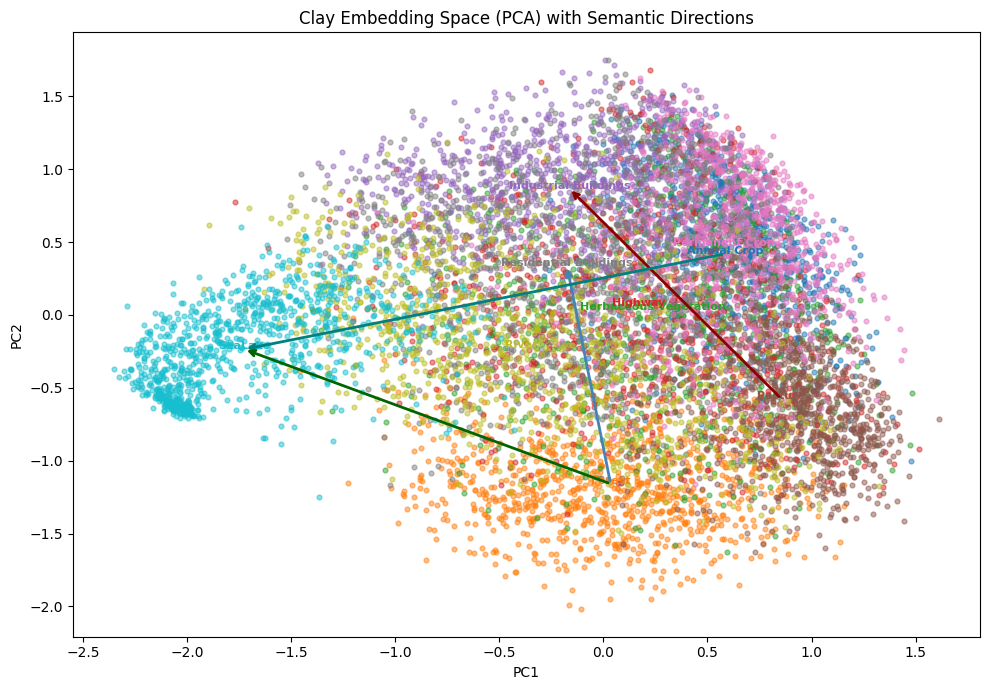

In [6]:
pca = PCA(n_components=2, random_state=SEED)
emb2d = pca.fit_transform(clay_emb)
cents2d = pca.transform(centroids)

fig, ax = plt.subplots(figsize=(10, 7))
cmap = plt.get_cmap("tab10")

for c in range(len(class_names)):
    m = labels == c
    ax.scatter(emb2d[m, 0], emb2d[m, 1], color=cmap(c), s=12, alpha=0.5)
    ax.annotate(class_names[c], cents2d[c], fontsize=8, fontweight="bold", color=cmap(c), ha="center")

# Draw direction arrows between centroid pairs
arrow_pairs = [
    ("Forest", "Residential Buildings", "steelblue"),
    ("Pasture", "Industrial Buildings",  "darkred"),
    ("Annual Crop", "SeaLake", "teal"),
    ("Forest", "SeaLake", "darkgreen"),

]
for src_name, tgt_name, color in arrow_pairs:
    s, t = cents2d[class_name_to_idx[src_name]], cents2d[class_name_to_idx[tgt_name]]
    ax.annotate("", xy=t, xytext=s, arrowprops=dict(arrowstyle="->", color=color, lw=2))

ax.set_title("Clay Embedding Space (PCA) with Semantic Directions")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("../figures/02_semantic_directions.png", dpi=150, bbox_inches="tight")
plt.show()

## Interpolation: Path Between Two Classes

Visualise latent-space walk from one class centroid to another class centroid: at each point along that path retrieve the real tile whose embedding is closest.

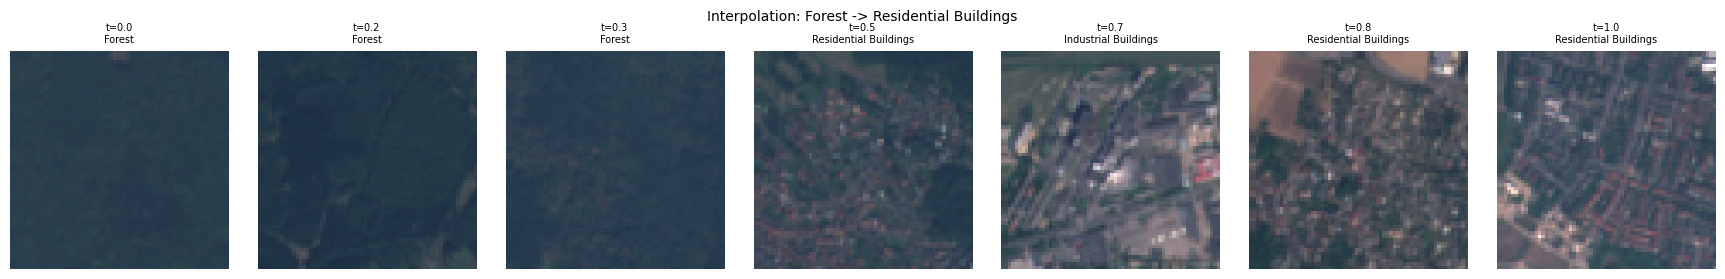

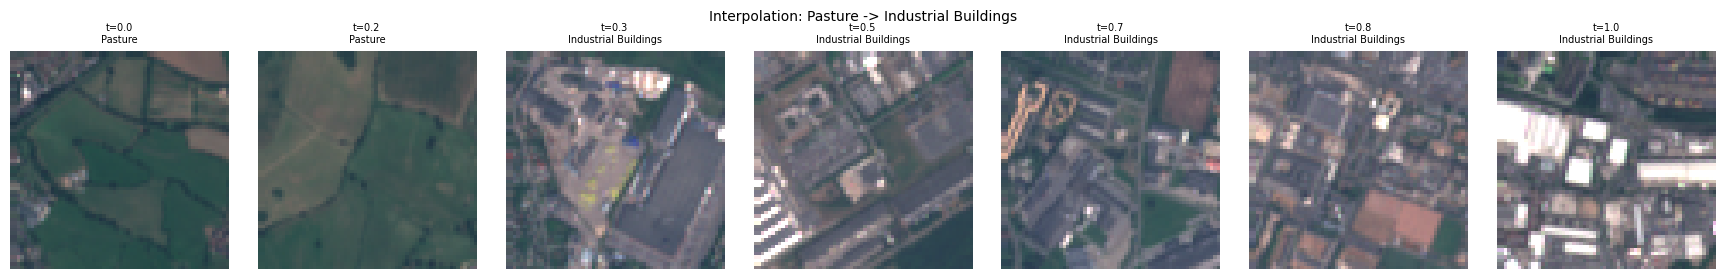

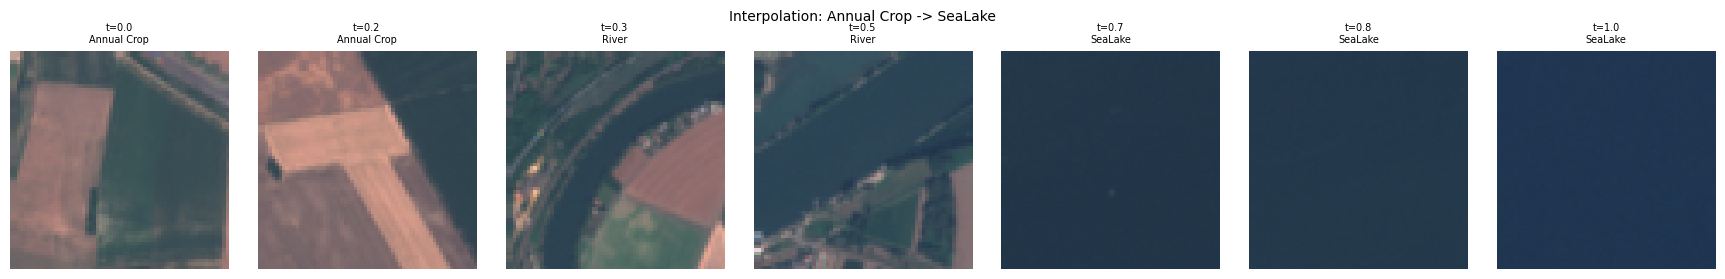

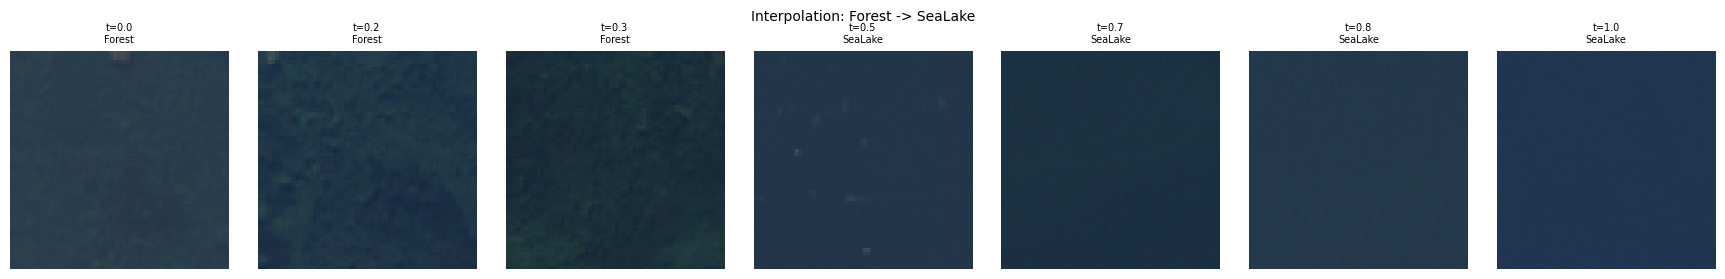

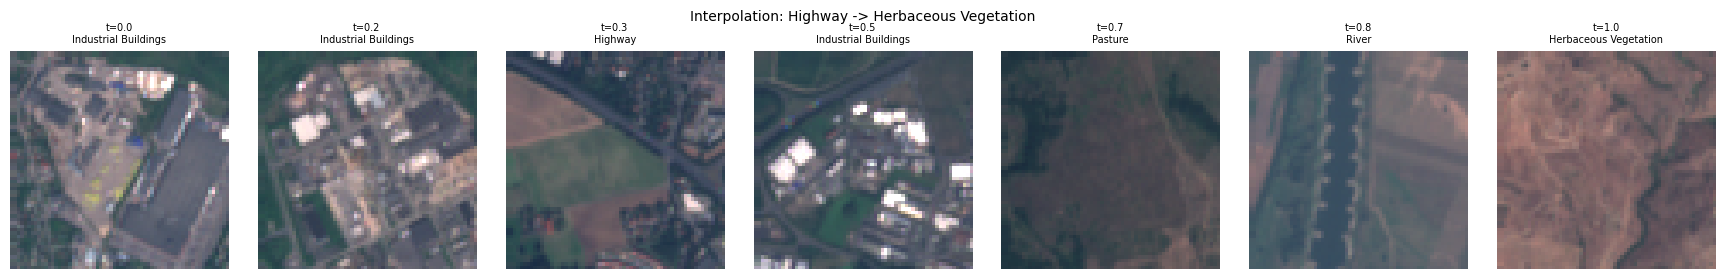

In [7]:
# Interpolate between Forest and Residential centroids. At each step, find the nearest tile and visualise it.

def latent_space_walk(src_name: str, tgt_name: str):
    src_c = class_name_to_idx[src_name]
    tgt_c = class_name_to_idx[tgt_name]
    n_steps = 7

    E_norm = normalize(clay_emb.astype(np.float32))

    fig, axes = plt.subplots(1, n_steps, figsize=(2.5 * n_steps, 2.8))
    used = set()

    for step, t in enumerate(np.linspace(0, 1, n_steps)):
        query = (1 - t) * centroids[src_c] + t * centroids[tgt_c]
        query_norm = query / (np.linalg.norm(query) + 1e-8)
        sims = query_norm @ E_norm.T
        for j in np.argsort(sims)[::-1]:
            if j not in used:
                used.add(j)
                break
        arr = images[j]
        rgb = msi_to_rgb(arr if arr.shape[0] == 13 else arr.transpose(2, 0, 1))
        axes[step].imshow(rgb)
        axes[step].axis("off")
        axes[step].set_title(f"t={t:.1f}\n{class_names[labels[j]]}", fontsize=7)

    plt.suptitle(f"Interpolation: {src_name} -> {tgt_name}", fontsize=10)
    plt.tight_layout()
    plt.show()

latent_space_walk(src_name="Forest", tgt_name="Residential Buildings")
latent_space_walk(src_name="Pasture", tgt_name="Industrial Buildings")
latent_space_walk(src_name="Annual Crop", tgt_name="SeaLake")
latent_space_walk(src_name="Forest", tgt_name="SeaLake")
latent_space_walk(src_name="Highway", tgt_name="Herbaceous Vegetation")
